In [1]:
import sqlite3

# Connect (creates database if not exists)
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create sales table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Insert sample data
sales_data = [
    ("Widget A", 10, 2.5),
    ("Widget B", 5, 3.0),
    ("Widget A", 7, 2.5),
    ("Widget C", 12, 1.8),
    ("Widget B", 8, 3.0),
    ("Widget C", 4, 1.8)
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sales_data)

# Commit changes and close connection
conn.commit()
conn.close()

print("Database and table created, sample data inserted.")


Database and table created, sample data inserted.


In [3]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect("sales_data.db")

# SQL query
query = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""

# Execute query and load into DataFrame
df = pd.read_sql_query(query, conn)

# Close connection
conn.close()

# Display DataFrame
print(df)


    product  total_qty  revenue
0  Widget A         17     42.5
1  Widget B         13     39.0
2  Widget C         16     28.8


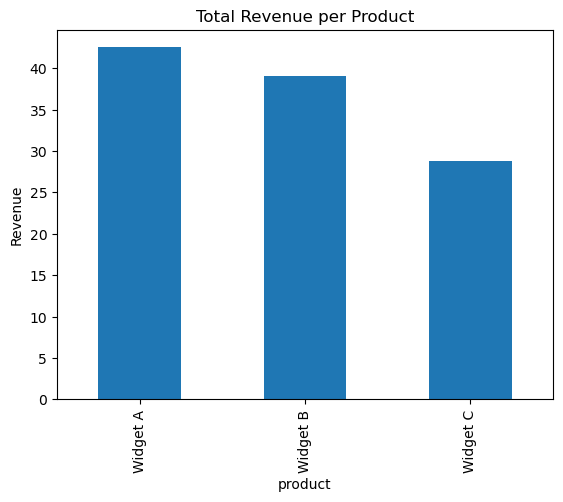

In [5]:
import matplotlib.pyplot as plt

# Plot revenue per product
df.plot(kind='bar', x='product', y='revenue', legend=False)

# Add labels and title
plt.ylabel("Revenue")
plt.title("Total Revenue per Product")

# Optional: save the figure
plt.savefig("sales_chart.png")

# Show the plot
plt.show()
